In [1]:
import cfa
from cfa import factor, consensus

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "8" # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = "8" # export OPENBLAS_NUM_THREADS=4 
os.environ["MKL_NUM_THREADS"] = "8" # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = "8" # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = "8" # export NUMEXPR_NUM_THREADS=6

In [3]:
import numpy as np
import tensorly as tl
from tensorly.cp_tensor import CPTensor
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn as sk
from sklearn import decomposition, preprocessing
import umap
import os 
np.random.seed(0)
FIG_DIR = "../figures/"

/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load bulk barcode
files = pd.Index(glob.glob("../data/X_cell_*.csv"))
# files = files[~files.str.contains("Rest")]
celltypes = [f.split("norm_")[-1].split(".csv")[0] for f in files]
df_all = [pd.read_csv(f, sep = " ") for f in files]

In [5]:
# split by timepoint and assemble tensor
timepoints = [[s.split("_")[0] for s in np.array(df.columns)] for df in df_all]
timepoints = timepoints[0]
celltypes = [df.columns[0].split("_")[1] for df in df_all]
X = np.dstack([df.to_numpy() for df in df_all])
# barcode x timepoint x celltype 
X = np.log1p(X)
X = tl.tensor(X, dtype = tl.float32)
bc = df_all[0].index

In [6]:
# Load RNA-seq
X_expr_full = pd.read_csv("../data/X_expr_avg.csv", sep = " ");
X_expr = X_expr_full # pd.read_csv("../data/X_expr_avg.csv", sep = " ");
df_meta_expr = pd.read_csv("../data/X_rna_metadata.csv", sep = " ")
# HVGs
X_expr = X_expr.loc[:, df_meta_expr.loc[:, "vst.variable"]]
# Select genes based on variance
# hvgs = df_meta_expr.loc[:, "vst.variance.standardized"] > np.quantile(df_meta_expr.loc[:, "vst.variance.standardized"], 0.25)
# X_expr = X_expr.loc[:, hvgs]
# filter genes
keep_genes = ~X_expr.columns.str.contains("^AC|^AP|^AL")
keep_genes.sum()
# filter cells for detection in barcode
in_expr = np.array([b in X_expr.index for b in bc])
bc_in_expr = bc[in_expr]
X_expr_subset = X_expr.loc[bc_in_expr, :].loc[:, keep_genes]
X = X[in_expr, :, :]
# Load surface marker data
X_marker = pd.read_csv("../data/X_marker_avg.csv", sep = " ")
X_marker_subset = X_marker.loc[X_expr_subset.index, :]

In [7]:
# Dimensionality reduction
X_pca = sk.decomposition.PCA().fit_transform(X.reshape(X.shape[0], -1))
X_umap = umap.UMAP(metric = "euclidean", n_neighbors = 25, spread = 2.0, min_dist = 0.9, random_state = 42).fit_transform(X_pca)
X_expr_pca = sk.decomposition.PCA().fit_transform(X_expr_subset)
X_expr_umap = umap.UMAP(n_neighbors=25, min_dist = 0.9, metric = "euclidean", random_state = 42).fit_transform(X_expr_pca)
X_marker_pca = sk.decomposition.PCA().fit_transform(X_marker_subset)
X_marker_umap = umap.UMAP(n_neighbors=25, min_dist = 0.9, metric = "euclidean", random_state = 42).fit_transform(X_marker_pca)

/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [8]:
# Build Laplacian on RNA data using kNN
A_dict = {}
D_dict= {}
for (n, _X) in zip(["barcode", "RNA", "marker"], [X_pca, X_expr_pca, X_marker_pca]):
    A = np.array(sk.neighbors.NearestNeighbors(n_neighbors = 25).fit(_X).kneighbors_graph().todense())
    A = (A + A.T)/2
    A_lap = A / (A.sum(-1).reshape(-1, 1) * A.sum(-1).reshape(1, -1))**0.5
    D_lap = np.eye(A.shape[0])
    A_dict[n] = A_lap
    D_dict[n] = D_lap

In [9]:
# tensor setting
Xb = X 
Xe = X_expr_subset.to_numpy() + 1e-6
Xm = X_marker_subset.to_numpy() + 1e-6

In [12]:
from tqdm import tqdm

k = 16
lamda_b = 1 / np.linalg.norm(Xb)**2
lamda_e = 1 / np.linalg.norm(Xe)**2
lamda_m = 1 / np.linalg.norm(Xm)**2
mu_1, mu_2 = [0, 0.1, ]
mu_lap = 0

model_params = {"params" : {"lamda_b" : lamda_b, "lamda_e" : lamda_e, "lamda_m" : lamda_m, "mu_1" : mu_1, "mu_2" : mu_2, "mu_lap" : mu_lap}, 
                "reg" : {"D_lap" : sum([d for (k, d) in D_dict.items()]), "A_lap" : sum([a for (k, a) in A_dict.items()])}, 
                "iters" : 500,
                "normalize_activities" : True,
                "print_iter" : 100,
                "verbose" : False,
                "check_convergence" : 10}

n = 25 # number of models per consensus
m = 10 # number of consensus models 

np.random.seed(0)
seeds = [np.random.randint(0, 1_000_000, n) for _ in range(m)]
cfa_models = [consensus.ConsensusFactorModel(k = k, n_reps = m, model_params = model_params, random_states = s) for s in seeds]
for cfa_model in cfa_models:
    cfa_model.fit({"Xb" : X, "Xe" : Xe, "Xm" : Xm})

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:06<00:00,  2.66s/it]


In [18]:
for cfa_model in cfa_models:
    cfa_model.get_consensus_factors()

/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packa

In [19]:
dimred_op = sk.decomposition.PCA()
dimred_op.fit(cfa_models[0].factor_aggregate.T)
ys = [dimred_op.transform(cfa_model.factor_aggregate.T) for cfa_model in cfa_models]

<Axes: >

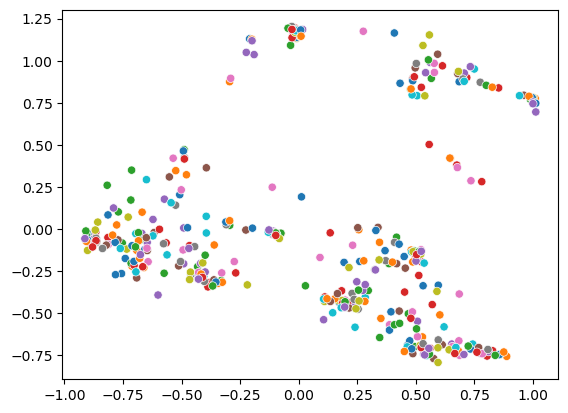

In [20]:
y = ys[3]
sb.scatterplot(x = y[:, 0], y = y[:, 1], hue = cfa_model.factor_run_id, palette = "tab10", legend = None)

In [25]:
import ot
import munkres

def to_perm(n, pairs):
    A = np.zeros((n, n), dtype = int)
    for (i, j) in pairs:
        A[i, j] = 1
    return A

facs = {k: [np.vstack([x[k] for x in cfa_models[i].cons_factors]) for i in range(len(cfa_models))] for k in cfa_models[0].factor_keys}
costs = {k: [ot.dist(facs[k][0], facs[k][i], metric = "correlation") for i in range(len(cfa_models))] for k in cfa_models[0].factor_keys}
perms = [to_perm(cfa_models[0].k, munkres.Munkres().compute(sum([costs[k][i] for k in cfa_models[0].factor_keys]))) for i in range(len(cfa_models))]

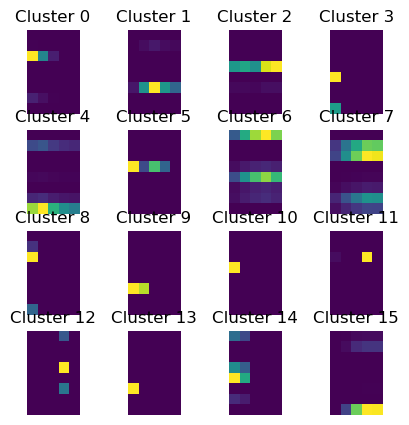

In [26]:
plt.figure(figsize = (5, 5))
for (i, c) in enumerate(cfa_models[0].cons_factors):
    plt.subplot(4, 4, i+1)
    plt.imshow(np.outer(c["Vb_1"], c["Vb_0"]))
    plt.axis("off")
    plt.title(f"Cluster {i}")

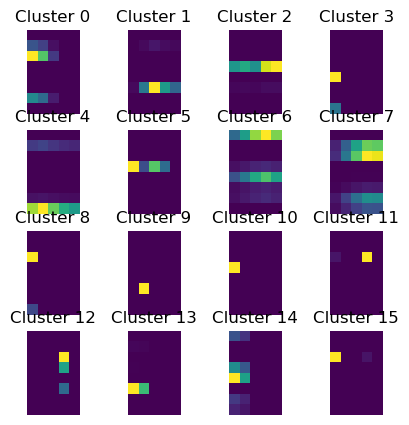

In [27]:
j = 7
plt.figure(figsize = (5, 5))
for (i, c) in enumerate([cfa_models[j].cons_factors[i] for i in perms[j].argmax(1)]):
    plt.subplot(4, 4, i+1)
    plt.imshow(np.outer(c["Vb_1"], c["Vb_0"]))
    plt.axis("off")
    plt.title(f"Cluster {i}")

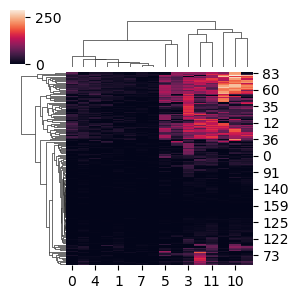

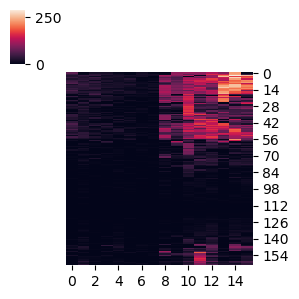

In [28]:
cg = sb.clustermap(np.vstack([cfa_models[0].cons_factors[i]["Vm"] for i in range(cfa_models[0].k)]).T, figsize = (3, 3))
j = 0
tmp = np.vstack([cfa_models[j].cons_factors[i]["Vm"] for i in range(cfa_models[0].k)]).T
sb.clustermap((tmp @ perms[j].T)[cg.dendrogram_row.reordered_ind, :][:, cg.dendrogram_col.reordered_ind], figsize = (3, 3), row_cluster = False, col_cluster = False)

In [53]:
fa_cons = factor.LinearFactorModel(k, learn_factors = [], **model_params)
consensus_factors = {k : np.vstack([cfa_models[0].cons_factors[i][k] for i in range(fa_cons.k)]).T for k in cfa_models[0].factor_keys}
fa_cons.factors = consensus_factors.copy()

In [54]:
fa_cons.fit({"Xb" : X, "Xe" : Xe, "Xm" : Xm});

/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


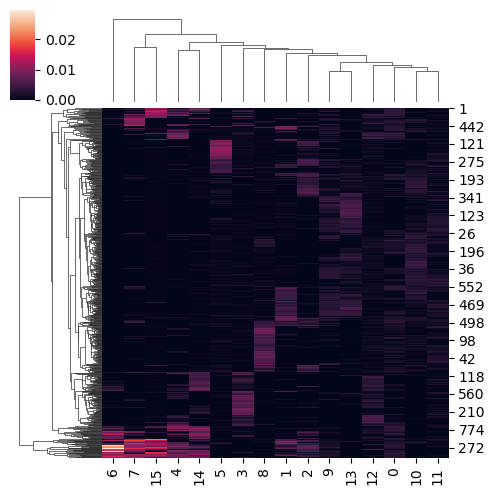

In [55]:
cg = sb.clustermap(fa_cons.activities, figsize = (5, 5))

In [56]:
fa_cons.learn_factors = list(fa_cons.factors.keys())
fa_cons.fit({"Xb" : X, "Xe" : Xe, "Xm" : Xm}) ;

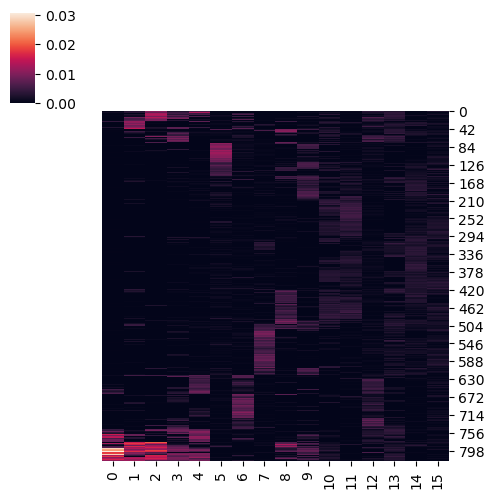

In [57]:
sb.clustermap(fa_cons.activities[cg.dendrogram_row.reordered_ind, :][:, cg.dendrogram_col.reordered_ind], figsize = (5, 5), row_cluster = False, col_cluster = False)

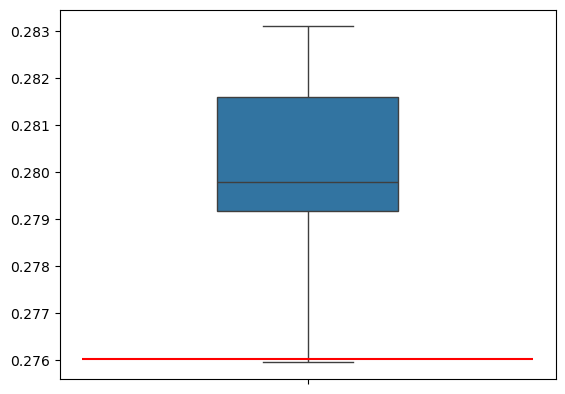

In [73]:
sb.boxplot([m.trace[-1] for m in cfa_model.models])
plt.hlines(fa_cons.trace[-1], -1, 1, color = "red")